## DFT vs. MLIPs Energy Comparison Pipeline

This notebook compares 
$$E_{ads}^{MLIP} = E_{slab+ads}^{MLIP} - E_{slab}^{DFT} - \sum E_{refs}^{DFT} \\
\text{ and } \\ 
E_{ads}^{DFT} = E_{slab+ads}^{DFT} - E_{slab}^{DFT} - \sum E_{refs}^{DFT} $$
where refs are DFT potential energies of gas-phase reference molecules.

In [ ]:
# TODO: write notebook description

**Directory Setup** \
To run this notebook, make sure your directory structure mimics this:

Note that the data in dft-data/ can be switched out with other DFT run data if you 
1. follow the existing directory structure
2. update the path format template in the user input cell below

#### 0. Configuration

In [44]:
from ase.io import iread, read, write

In [45]:
# builds a dict describing 1 DFT adsorbate run
# ads: single adsorbate string or two joined like ads1_ads2
# template: path template string with {ads}, {slab}, {config_id} placeholders;
#           define at call site (TEMPLATE in next cell) to handle
#           directory structure variants.

def make_run(ads, slab, config_id, template):
    run_id = f"{ads}_{slab}_{config_id}"
    return {
        "ads":       ads,
        "slab":      slab,
        "config_id": config_id,  # use arbitrary directory numbering to label ads config for now
        "run_id":    run_id,
        "path":      template.format(ads=ads, slab=slab, config_id=config_id),
    }

def make_model(name, python_bin, script_path):
    return {
        "name":       name,
        "python_bin": python_bin,
        "script":     script_path
    }

In [46]:
# USER INPUT HERE

# do you want to re-run model relaxations? (note: takes time!)
RUN_RELAXATIONS = False  # set to True when ready

# directory path template for adsorbate systems on YPdCu slab
YPDCU_TEMPLATE = "dft-data/YPdCu/{ads}_on_{slab}/{ads}_{slab}_{config_id}/vasprun.xml"

RUNS = (
    [make_run("CH3CHO",       "YO4PdCu", 3, YPDCU_TEMPLATE)] +
    [make_run("CO_CHO",       "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 15)] +
    [make_run("COCHO",        "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 19)] +
    [make_run("COOH",         "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 16)]
)

MODELS = [
    make_model("MACE",       "/Users/zschwab/miniconda3/envs/mlip-mace/bin/python",       "model-scripts/run_mace.py"     ),
    make_model("MatterSim",  "/Users/zschwab/miniconda3/envs/mlip-mattersim/bin/python",  "model-scripts/run_mattersim.py"),
    make_model("UMA",        "/Users/zschwab/miniconda3/envs/mlip-uma/bin/python",        "model-scripts/run_uma.py"      ),
]

#### 1. DFT data ingestion 
(extract all frames from DFT runs)

In [47]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    return frames

# for single-structure files (references, loads last by default)
def load_frame(path, index=-1):
    frame = read(path, index=index)
    return frame

In [48]:
# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later

if RUN_RELAXATIONS:
    for run in RUNS:
        write(f"dft-trajectories/{run['run_id']}_dft.xyz", load_frames(run['path']))
else:
    print("Cell skipped!")

Cell skipped!


#### 2. run MLIPs (MACE, MatterSim, UMA)

In [ ]:
if RUN_RELAXATIONS:
    # find device to run model on
    import torch

    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        device = "mps"   # for apple silicon gpus (M-series chips)
    elif torch.cuda.is_available():
        device = "cuda"  # for gpus w/ nvidia cuda backend
    else:
        device = "cpu"   # default 

In [ ]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

import subprocess
import os

if RUN_RELAXATIONS:
    # new env inherits current environment as a starting point
    env = os.environ.copy()

    # disable GUI dependencies vscode auto-imports when launching a subprocess from
    # a python notebook b/c they conflict with model dependencies and are unneeded
    env["MPLBACKEND"] = "Agg"

    for model in MODELS:
        for run in RUNS:
            # in: path to POSCAR files of dft runs
            in_path = f"dft-data/YPdCu/{run['ads']}_on_{run['slab']}/{run['run_id']}/POSCAR"
            out_path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"
            r = subprocess.run(
                [model['python_bin'], model['script'], in_path, out_path, device],
                capture_output=True, text=True, env=env
            )
            if r.returncode != 0:
                print(f"-- [{run['run_id']}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
            else:
                print(f"-- [{run['run_id']}] ({model['name']}): success")
else:
    print("Cell skipped!")

Cell skipped!


#### 3. Calculate adsorbate energies

In [ ]:
# get bare slab & reference energies

REFS= {  # reference adsorbate energies
    "CO" :  None,
    "CO2":  None,
    "H2" :  None,
    "H2O":  None,
}

for mol in REFS:
    REFS[mol] = load_frame(f"../../dft-ref-energy-data/adsorbates/{mol}_gas/vasprun.xml").get_potential_energy()

slab = load_frame("../../dft-ref-energy-data/slabs/YO4PdCu/vasprun.xml")
slab_energy = slab.get_potential_energy()

In [ ]:
# define formulas for E_adsorbed = E_total - E_slab - E_adsorbates

def calc_CH3CHO(total_energy):
    return total_energy - slab_energy + REFS["H2O"] - 2*REFS["CO"] - 3*REFS["H2"]

def calc_COCHO(total_energy):
    return total_energy - slab_energy - 2*REFS["CO"] - (1/2)*REFS["H2"]

def calc_COOH(total_energy):
    return total_energy - slab_energy - REFS["CO2"] - (1/2)*REFS["H2"]

In [ ]:
# calculate adsorbate energies from bare slab & reference energies
ADSORBATE_CALCS = {
    "CH3CHO": calc_CH3CHO,
    "CO_CHO": calc_COCHO,
    "COCHO" : calc_COCHO,
    "COOH"  : calc_COOH,
}

# initialize keys for dict of mlip energies
mlip_energies = {
    model['name']: {ads: {} for ads in ADSORBATE_CALCS}
    for model in MODELS
}

for model in MODELS:
    for run in RUNS:
        path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"
        atoms = read(path, index=-1)
        total_e = atoms.get_potential_energy()
        mlip_energies[model['name']][run['ads']][run['run_id']] = {  # index by model name for plotting later
            "total":    total_e,
            "adsorbed": ADSORBATE_CALCS[run['ads']](total_e)
        }

#### 4. Plot results

In [105]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

# initialize keys for dict of dft energies
dft_energies = {ads: {} for ads in ADSORBATE_CALCS}

for run in RUNS:
    atoms = read(f"dft-trajectories/{run['run_id']}_dft.xyz", index=-1)
    total = atoms.get_potential_energy()
    dft_energies[run['ads']][run['run_id']] = {  # index by adsorbate for easier plotting later
        "total":    total,
        "adsorbed": ADSORBATE_CALCS[run['ads']](total)
    }
#

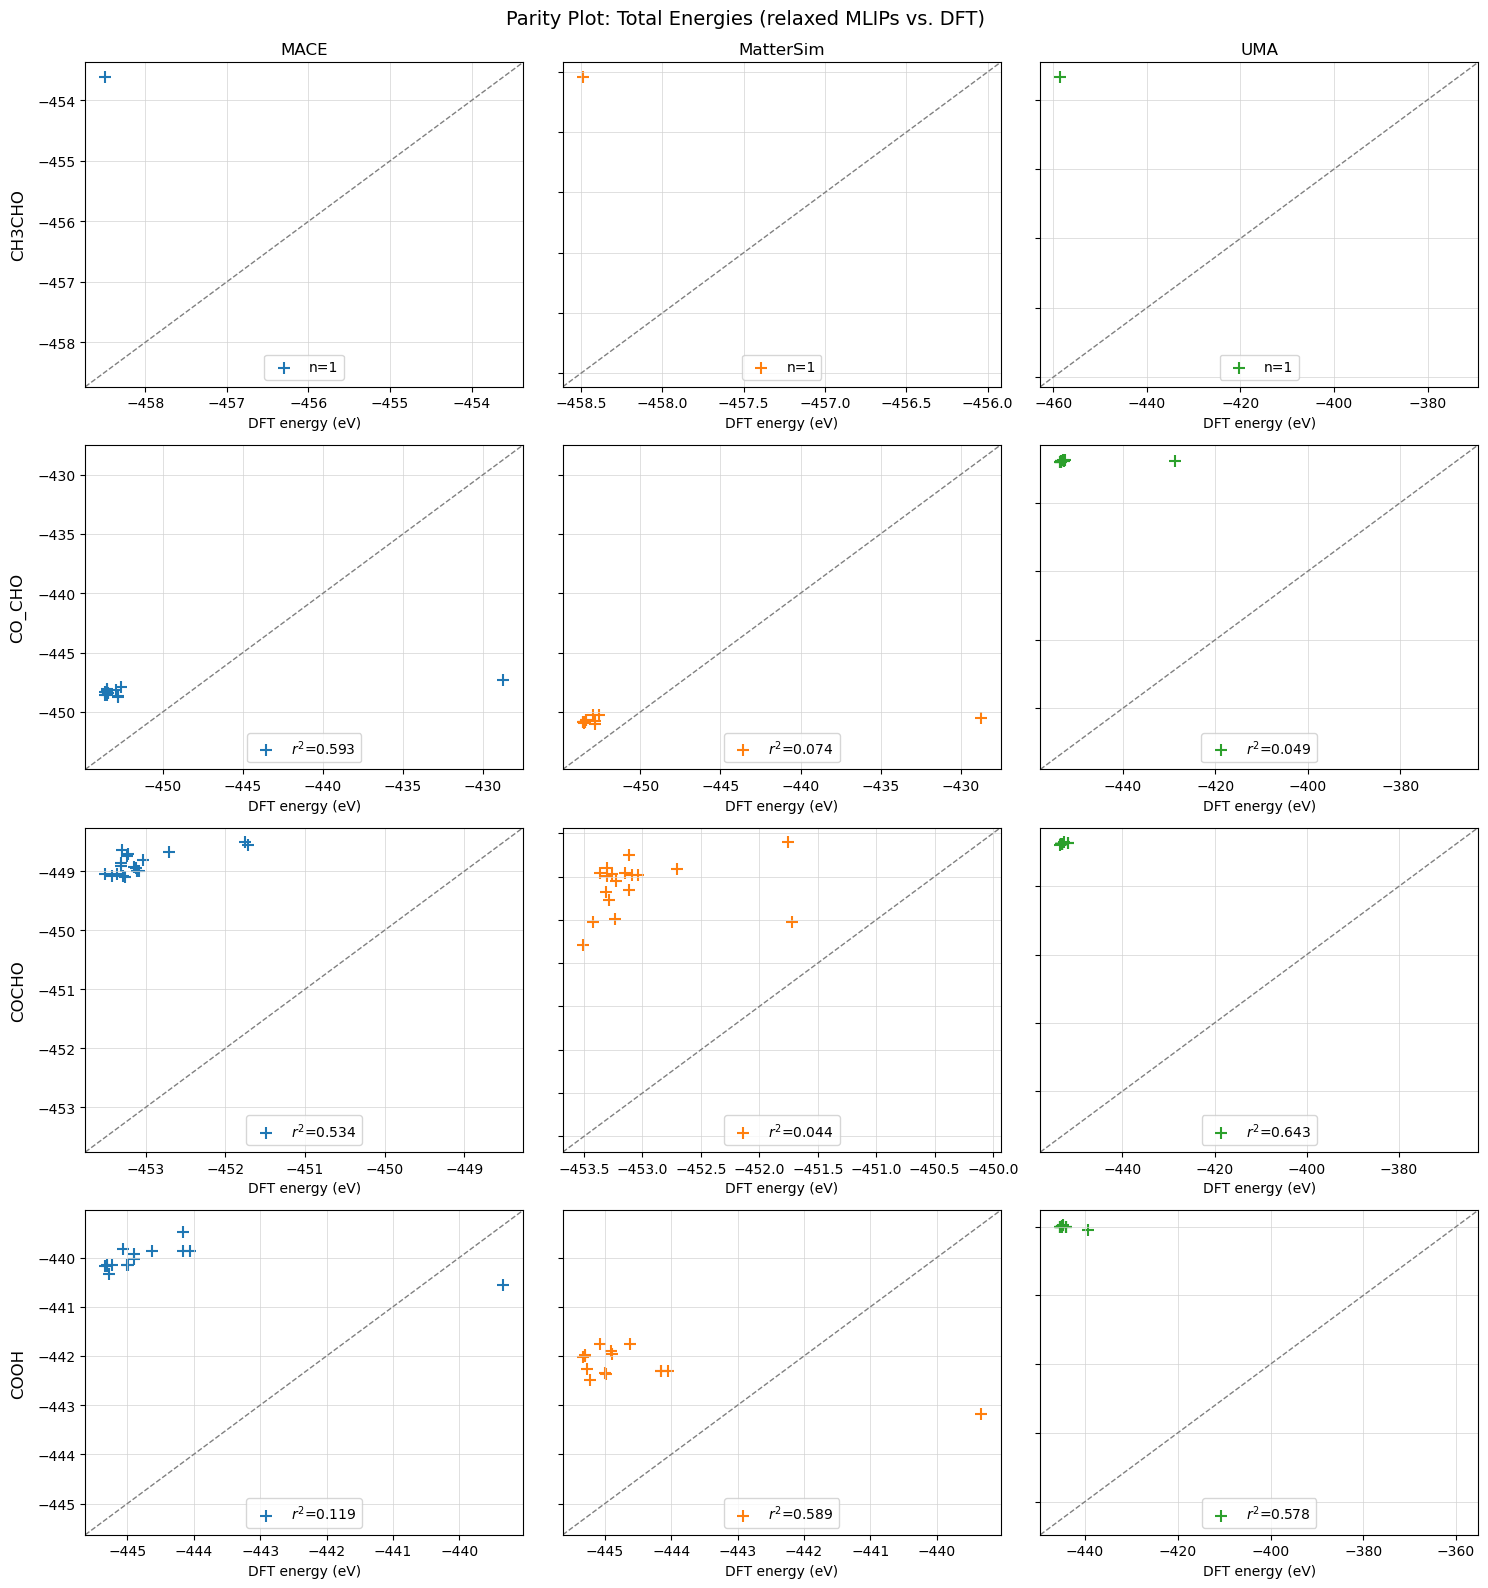

In [109]:
# fig. 1: parity plot (total energies)

fig, axes = plt.subplots(nrows=len(ADSORBATE_CALCS), ncols=len(MODELS),
                        figsize=(5*len(MODELS), 4*len(ADSORBATE_CALCS)))

for row, ads in enumerate(ADSORBATE_CALCS):
    colors = plt.cm.tab10.colors
    for col, (model, color) in enumerate(zip(MODELS, colors)):
        ax = axes[row][col]
        
        # get data
        x = [v['total'] for v in dft_energies[ads].values()]
        y = [v['total'] for v in mlip_energies[model['name']][ads].values()]
                
        # calculate r^2
        if len(x) >= 2:  # use pearson r^2 b/c insensitive to different energy offsets
            r2_p = pearsonr(x, y).statistic ** 2
            # r2 = r2_score(x, y)
            label = f"$r^2$={r2_p:.3f}"
        else:
            label = "n=1"
        
        # plot data
        ax.scatter(x, y, marker='+', s=80, label=label, color=color)
        ax.legend(loc='lower center')

        # padded limits
        padding = 0.05 * (max(x + y) - min(x + y))
        lim = [min(x + y) - padding, max(x + y) + padding]
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        
        # diagonal
        ax.plot(lim, lim, color='gray', linestyle='--', linewidth=1)
        
        # appearance
        ax.grid(color='lightgrey', linewidth=0.5)
        ax.set_xlabel("DFT energy (eV)")
        if col == 0:
            ax.set_ylabel("MLIP energy (eV)")
        else:
            ax.set_yticklabels([])
        
        axes[0][col].set_title(model['name'], fontsize=12)    
    axes[row][0].set_ylabel(ads, fontsize=12, labelpad=8)

plt.suptitle("Parity Plot: Total Energies (relaxed MLIPs vs. DFT)", y=0.99, fontsize=14)
plt.tight_layout()
plt.show()

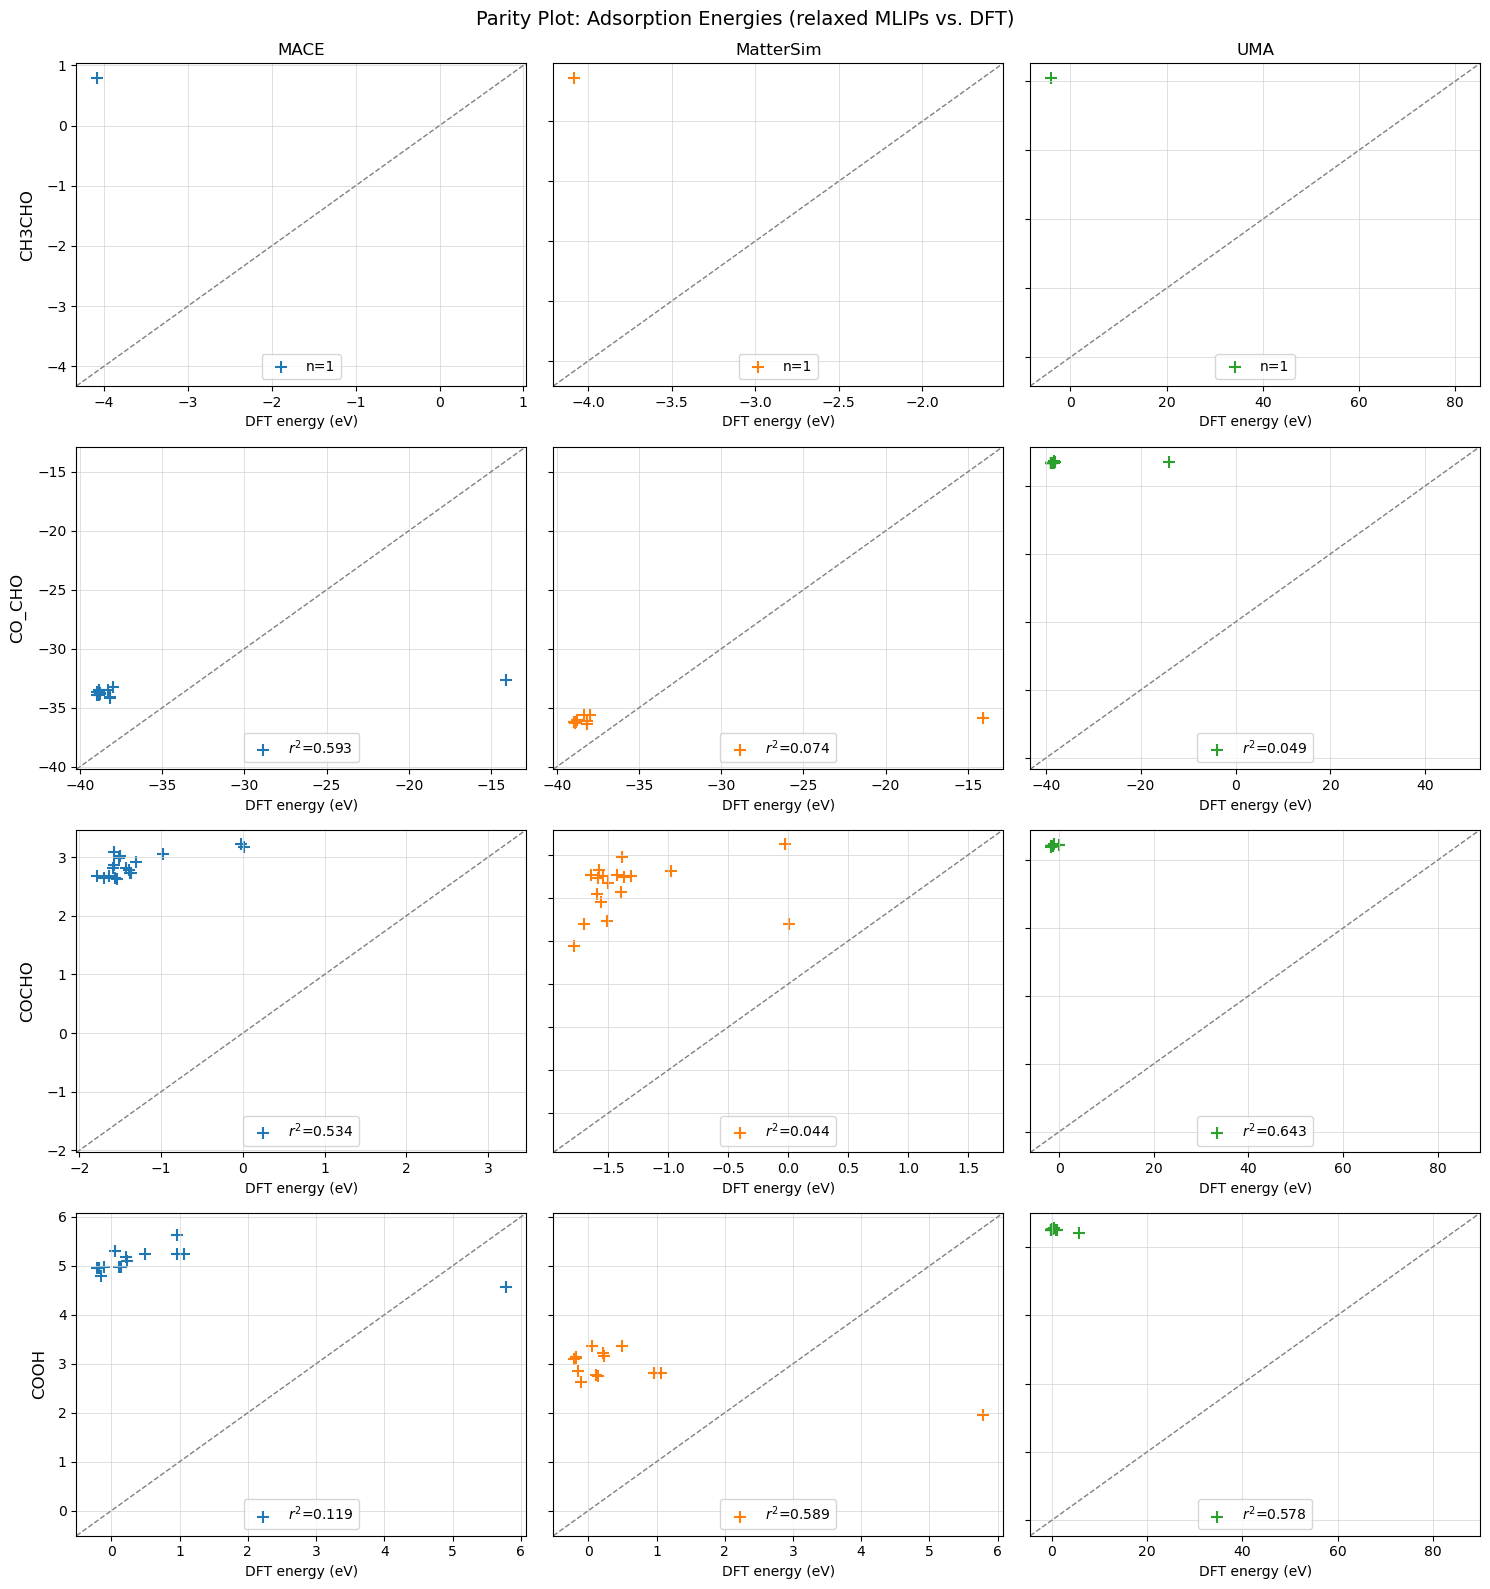

In [110]:
# fig. 2: parity plot (adsorption energies)

fig, axes = plt.subplots(nrows=len(ADSORBATE_CALCS), ncols=len(MODELS),
                        figsize=(5*len(MODELS), 4*len(ADSORBATE_CALCS)))

for row, ads in enumerate(ADSORBATE_CALCS):
    colors = plt.cm.tab10.colors
    for col, (model, color) in enumerate(zip(MODELS, colors)):
        ax = axes[row][col]
        
        # get data
        x = [v['adsorbed'] for v in dft_energies[ads].values()]
        y = [v['adsorbed'] for v in mlip_energies[model['name']][ads].values()]
                
        # calculate r^2
        if len(x) >= 2:  # use pearson r^2 b/c insensitive to different energy offsets
            r2_p = pearsonr(x, y).statistic ** 2
            # r2 = r2_score(x, y)
            label = f"$r^2$={r2_p:.3f}"
        else:
            label = "n=1"
        
        # plot data
        ax.scatter(x, y, marker='+', s=80, label=label, color=color)
        ax.legend(loc='lower center')

        # padded limits
        padding = 0.05 * (max(x + y) - min(x + y))
        lim = [min(x + y) - padding, max(x + y) + padding]
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        
        # diagonal
        ax.plot(lim, lim, color='gray', linestyle='--', linewidth=1)
        
        # appearance
        ax.grid(color='lightgrey', linewidth=0.5)
        ax.set_xlabel("DFT energy (eV)")
        if col == 0:
            ax.set_ylabel("MLIP energy (eV)")
        else:
            ax.set_yticklabels([])
        
        axes[0][col].set_title(model['name'], fontsize=12)    
    axes[row][0].set_ylabel(ads, fontsize=12, labelpad=8)

plt.suptitle("Parity Plot: Adsorption Energies (relaxed MLIPs vs. DFT)", y=0.99, fontsize=14)
plt.tight_layout()
plt.show()

In [101]:
# outlier lookup: for a given ads + model, print all points sorted by MLIP deviation
def outlier_lookup(ads, model_name, energy_key="adsorbed"):
    x_dict = dft_energies[ads]
    y_dict = mlip_energies[model_name][ads]
    
    rows = []
    for run_id in x_dict:
        x = x_dict[run_id][energy_key]
        y = y_dict[run_id][energy_key]
        rows.append((run_id, x, y, abs(y - x)))
    
    rows.sort(key=lambda r: r[3], reverse=True)
    print(f"{'run_id':<30} {'DFT':>10} {'MLIP':>10} {'|E_MLIP - E_DFT|':>10}")
    print("-" * 62)
    for run_id, x, y, dev in rows:
        print(f"{run_id:<30} {x:>10.3f} {y:>10.3f} {dev:>10.3f}")

# usage:
outlier_lookup("COOH", "MACE")

run_id                                DFT       MLIP |E_MLIP - E_DFT|
--------------------------------------------------------------
COOH_YO4PdCu_11                     0.048      5.300      5.252
COOH_YO4PdCu_15                    -0.214      4.956      5.170
COOH_YO4PdCu_14                    -0.184      4.961      5.146
COOH_YO4PdCu_12                    -0.185      4.957      5.142
COOH_YO4PdCu_7                     -0.107      4.967      5.075
COOH_YO4PdCu_1                      0.213      5.190      4.977
COOH_YO4PdCu_13                    -0.150      4.786      4.935
COOH_YO4PdCu_4                      0.226      5.099      4.872
COOH_YO4PdCu_10                     0.115      4.970      4.855
COOH_YO4PdCu_8                      0.135      4.971      4.836
COOH_YO4PdCu_5                      0.495      5.243      4.749
COOH_YO4PdCu_9                      0.965      5.629      4.664
COOH_YO4PdCu_3                      0.962      5.245      4.283
COOH_YO4PdCu_6                     

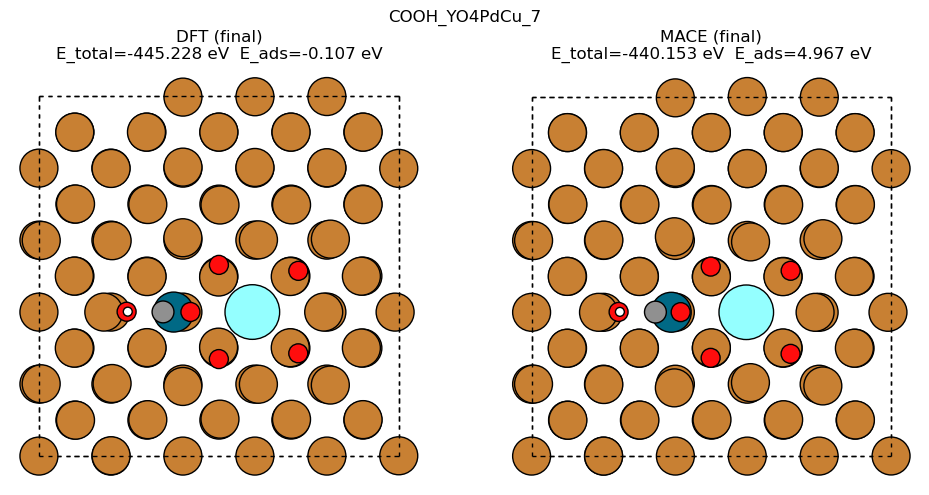

In [60]:
from ase.visualize.plot import plot_atoms

def plot_run_comparison(run_id, model_name, energy_key="adsorbed"):
    # find the run
    run = next(r for r in RUNS if r["run_id"] == run_id)
    
    # load final frames
    dft_frame  = read(f"dft-trajectories/{run_id}_dft.xyz", index=-1)
    mlip_frame = read(f"mlip-trajectories/{model_name}/{run_id}_{model_name.lower()}.traj", index=-1)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    for ax, atoms, label in zip(axes, [dft_frame, mlip_frame], ["DFT (final)", f"{model_name} (final)"]):
        plot_atoms(atoms, ax, radii=0.5, rotation=("0x,0y,0z"))
        e = atoms.get_potential_energy()
        e_ads = ADSORBATE_CALCS[run["ads"]](e)
        ax.set_title(f"{label}\nE_total={e:.3f} eV  E_ads={e_ads:.3f} eV")
        ax.axis("off")
    
    fig.suptitle(run_id)
    plt.tight_layout()
    plt.show()

# usage — paste the run_id from outlier_lookup output:
plot_run_comparison("COOH_YO4PdCu_7", "MACE")

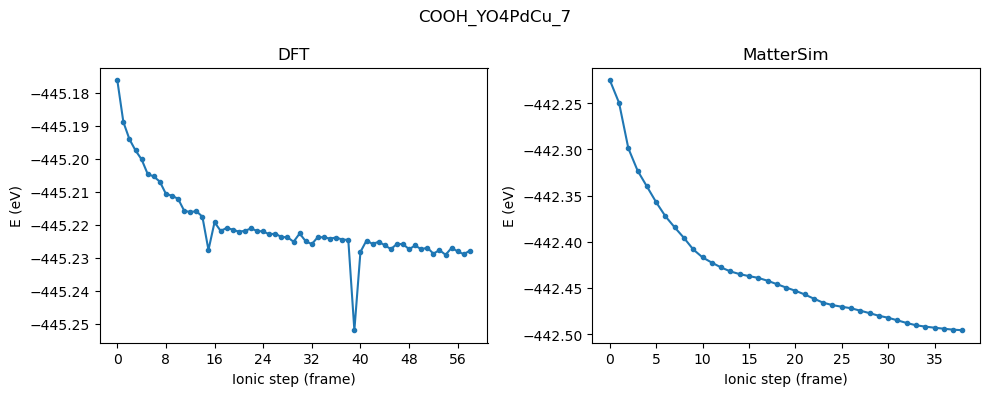

In [102]:
def plot_run_comparison(run_id, model_name):
    dft_frames  = [f for f in iread(f"dft-trajectories/{run_id}_dft.xyz")]
    mlip_frames = [f for f in iread(f"mlip-trajectories/{model_name}/{run_id}_{model_name.lower()}.traj")]
    
    dft_energies_traj  = [f.get_potential_energy() for f in dft_frames]
    mlip_energies_traj = [f.get_potential_energy() for f in mlip_frames]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    for ax, energies, label in zip(axes, [dft_energies_traj, mlip_energies_traj], ["DFT", model_name]):
        ax.plot(energies, marker='o', markersize=3)
        ax.set_title(label)
        ax.set_xlabel("Ionic step (frame)")
        ax.set_ylabel("E (eV)")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        # ax.set_xlim(0, len(energies) - 1)        
        # ax.grid(True, linestyle='--', alpha=0.5)
    
    fig.suptitle(run_id)
    plt.tight_layout()
    plt.show()

# use: enter run_id, model_name
plot_run_comparison("COOH_YO4PdCu_7", "MatterSim")

In [96]:
# write .cif to view a relaxation result in VESTA
from pathlib import Path

def render_vesta(run_id, model):
    if model=="DFT":
        filepath = f"dft-trajectories/{run_id}_{model.lower()}.xyz"
    else:
        filepath = f"mlip-trajectories/{model}/{run_id}_{model.lower()}.traj"
    atoms = read(filepath, index=-1)
    if not Path(f"vesta-renders/{run_id}_{model.lower()}.cif").exists():
        write(f"vesta-renders/{run_id}_{model}.cif", atoms)

render_vesta("COOH_YO4PdCu_7", "DFT")
render_vesta("COOH_YO4PdCu_7", "MACE")
render_vesta("COOH_YO4PdCu_7", "MatterSim")
render_vesta("COOH_YO4PdCu_7", "UMA")



In [103]:
for model in MODELS:
    for ads in ADSORBATE_CALCS:
        xk = list(dft_energies[ads].keys())
        yk = list(mlip_energies[model['name']][ads].keys())
        if xk != yk:
            print(f"{model['name']} / {ads}: KEY MISMATCH")
            print("  DFT:", xk)
            print("  MLIP:", yk)